In [5]:
from pathlib import Path
import sys
import scipy
import tqdm

# Add parent directory to Python path
project_root = Path("/home/nbyrnes/code/random-matrix/")  # <-- adjust this
sys.path.insert(0, str(project_root))
import sksparse
import matplotlib.pyplot as plt
import numpy as np
from random_matrix.modes import mode_grid_factory
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
import pickle
from random_matrix.utils import matrix_utils, geometry_utils

In [3]:
simulation_name = "memory_effect_test_v2"
ism = InputStatisticsManager.from_name(
    simulation_name, parent_data_dir="/mnt/raid/rmt/data/"
)
pm = ism.get_matrix_pool_manager()
mean_S = pm.mean_S
chol = pm.chol
cov = scipy.sparse.load_npz("/mnt/raid/rmt/data/memory_effect_test_v2/cov.npz")

Loading statistics from memory...


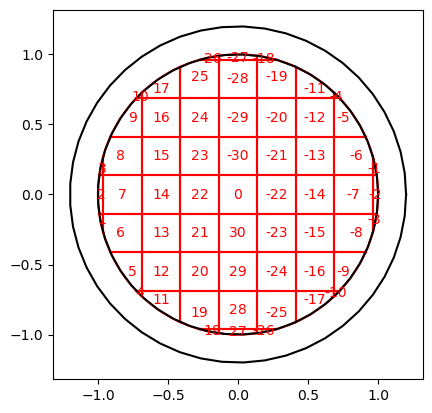

In [7]:
my_grid = mode_grid_factory.from_tiling(
    tiling_type="rectangles",
    side_length=(0.275, 0.275),
    r_lim=1.2,
    grid_wave_type="propagating",
    rotation_angle=0.0,
    translation_vector=np.array([0.0, 0.0]),
)
my_grid.plot(close=False, show_indices=True)


In [11]:
matrix_utils.get_cov_sub_block(cov, "t,t", (22,0,20,-24)).todense()

matrix([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

In [3]:
# pm.S_sampler(2, False)

4x4 Test

[-3.35803819e-20+0.00000000e+00j -4.02571819e-04+1.64451236e-08j
 -4.02571819e-04-1.64451236e-08j -5.51288472e-20+0.00000000e+00j
  2.45619430e-22+0.00000000e+00j  8.31619467e-25+0.00000000e+00j
  1.11133988e-37+0.00000000e+00j -3.73701171e-37+0.00000000e+00j]
-3


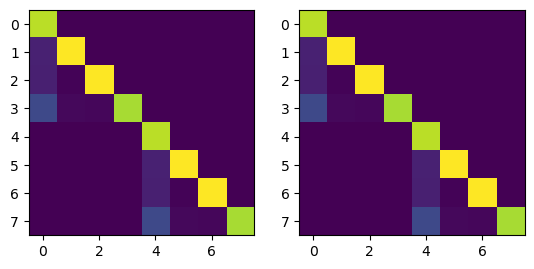

In [ ]:
block_str = "t"
block_str_repeat = f"{block_str},{block_str}"

cov_sub_block = matrix_utils.get_cov_sub_block(
    cov, block_str_repeat, (i, j, u, v)
).todense()
sigma_sub_block = 0.5 * np.block(
    [
        [np.real(cov_sub_block), np.imag(-cov_sub_block)],
        [np.imag(cov_sub_block), np.real(cov_sub_block)],
    ]
)
print(np.linalg.eigvals(sigma_sub_block))

for pow in range(-30, 0):
    try:
        chol_sub_block_sksparse = sksparse.cholmod.cholesky(
            scipy.sparse.csc_matrix(
                sigma_sub_block + 10**pow * np.identity(len(sigma_sub_block))
            ),
            ordering_method="natural",
        ).L()

        chol_sub_block = np.linalg.cholesky(
            sigma_sub_block + 10**pow * np.identity(len(sigma_sub_block))
        )

        break
    except sksparse.cholmod.CholmodNotPositiveDefiniteError:
        continue
    except np.linalg.LinAlgError:
        continue

print(pow)
fig, ax = plt.subplots(1, 2)
ax[0].imshow(np.abs(chol_sub_block_sksparse.todense()))
ax[1].imshow(np.abs(chol_sub_block))

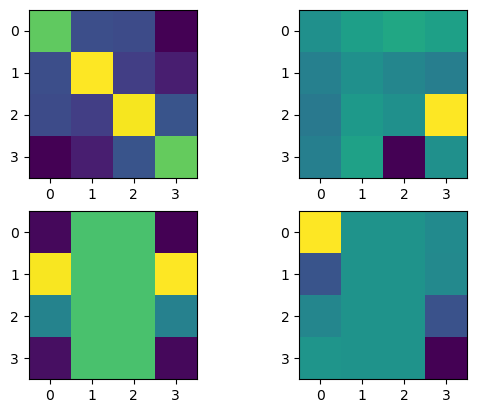

In [5]:
num_samples = 10**1
cov_test = np.zeros((4, 4), np.complex128)
for _ in range(num_samples):
    random_numbers = np.random.randn(8)
    random_numbers = chol_sub_block_sksparse @ random_numbers
    reals = random_numbers[0:4]
    imags = random_numbers[4:8]
    vals = reals + 1j * imags

    c = np.outer(vals, np.conj(vals))
    cov_test += c
cov_test /= num_samples

fig, ax = plt.subplots(2, 2)
ax[0, 0].imshow(cov_test.real)
ax[0, 1].imshow(cov_test.imag)
ax[1, 0].imshow(cov_sub_block.real)
ax[1, 1].imshow(cov_sub_block.imag)

In [6]:
print(cov_sub_block.imag)

[[ 6.68224325e-07 -4.78926206e-24 -8.56057621e-24 -4.63952107e-08]
 [-3.43436264e-07  1.44168733e-24  3.87983034e-24 -5.85743488e-08]
 [-7.16906849e-08 -3.95929306e-24 -1.36209449e-24 -3.56545634e-07]
 [ 1.34939772e-08 -8.75998205e-24 -4.58965098e-24 -7.01114572e-07]]


In [12]:
num_samples = 10**4
S = pm.S_sampler(num_samples, False)

cov_test = np.zeros((4, 4), np.complex128)
for mat in tqdm.tqdm(S):
    sb1 = np.ravel(matrix_utils.get_sub_block(mat, block_str, (i, j)))
    sb2 = np.ravel(matrix_utils.get_sub_block(mat, block_str, (u, v)))
    c = np.outer(sb1, np.conj(sb2))
    cov_test += c
cov_test /= num_samples

100%|██████████| 10000/10000 [00:00<00:00, 162002.91it/s]


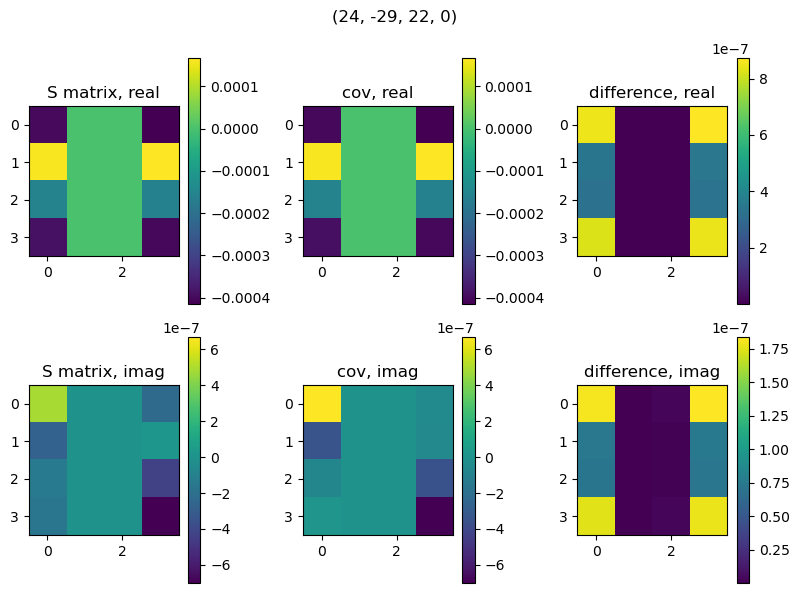

In [13]:
fig, ax = plt.subplots(2, 3, figsize=(8, 6))

real_vmin = np.min(cov_sub_block.real)
real_vmax = np.max(cov_sub_block.real)

imag_vmin = np.min(cov_sub_block.imag)
imag_vmax = np.max(cov_sub_block.imag)

# Display images and save the image objects for colorbars
im00 = ax[0, 0].imshow(cov_test.real, vmin=real_vmin, vmax=real_vmax)
ax[0, 0].set_title("S matrix, real")
fig.colorbar(im00, ax=ax[0, 0])

im10 = ax[0, 1].imshow(cov_sub_block.real, vmin=real_vmin, vmax=real_vmax)
ax[0, 1].set_title("cov, real")
fig.colorbar(im10, ax=ax[0, 1])

im02 = ax[0, 2].imshow(np.abs(cov_test.real - cov_sub_block.real))
ax[0, 2].set_title("difference, real")
fig.colorbar(im02, ax=ax[0, 2])

im01 = ax[1, 0].imshow(cov_test.imag, vmin=imag_vmin, vmax=imag_vmax)
ax[1, 0].set_title("S matrix, imag")
fig.colorbar(im01, ax=ax[1, 0])


im11 = ax[1, 1].imshow(cov_sub_block.imag, vmin=imag_vmin, vmax=imag_vmax)
ax[1, 1].set_title("cov, imag")
fig.colorbar(im11, ax=ax[1, 1])

im02 = ax[1, 2].imshow(np.abs(cov_test.imag - cov_sub_block.imag))
ax[1, 2].set_title("difference, imag")
fig.colorbar(im02, ax=ax[1, 2])


fig.suptitle(f"{i,j,u,v}")
plt.tight_layout()
plt.show()

In [9]:
print(cov_sub_block)

[[-4.02041395e-04+6.68224325e-07j -2.59947308e-21-4.78926206e-24j
   2.35617423e-21-8.56057621e-24j -4.15065231e-04-4.63952107e-08j]
 [ 1.61625037e-04-3.43436264e-07j  1.04501830e-21+1.44168733e-24j
  -9.47206943e-22+3.87983034e-24j  1.66860899e-04-5.85743488e-08j]
 [-1.54278709e-04-7.16906849e-08j -9.97510125e-22-3.95929306e-24j
   9.04158247e-22-1.36209449e-24j -1.59275854e-04-3.56545634e-07j]
 [-3.90454906e-04+1.34939772e-08j -2.52454409e-21-8.75998205e-24j
   2.28827864e-21-4.58965098e-24j -4.03102242e-04-7.01114572e-07j]]


In [10]:
print(i, j, u, v)

24 -29 22 0


In [11]:
print(sb)
print(np.outer(sb, np.conj(sb.T)))
print(np.diag(np.outer(sb, np.conj(sb))).real)

NameError: name 'sb' is not defined

In [ ]:
print(mat[0:2, 0:2])
sb = np.ravel(matrix_utils.get_sub_block(mat, block_str, (-30, -30)))
print(sb)

In [ ]:
assert False

In [ ]:
def block_ravel(arr):

    m, n = arr.shape

    if m % 2 != 0 or n % 2 != 0:
        raise ValueError("Array dimensions must be even for 2x2 blocks.")

    blocks = []
    for i in range(0, m, 2):
        for j in range(0, n, 2):
            block = arr[i : i + 2, j : j + 2]
            blocks.append(block.ravel())

    return np.concatenate(blocks)


# Example
A = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12], [13, 14, 15, 16]])

result = block_ravel(A)
print(result)

In [ ]:
import tqdm

cov_calculated = np.zeros(
    (
        (pm.single_pool_S[0].shape[0] // 2) ** 2,
        (pm.single_pool_S[0].shape[0] // 2) ** 2,
    ),
    dtype=np.complex128,
)
mean_S = np.load("/mnt/raid/rmt/data/memory_effect_test/mean_S.npy")
for S in tqdm.tqdm(pm.single_pool_S[:100]):
    S = S - mean_S
    sb1 = matrix_utils.get_block(S, "t")
    sb2 = matrix_utils.get_block(S, "t")
    sb1 = sb1 - np.eye(sb1.shape[0], dtype=sb1.dtype)
    sb2 = sb2 - np.eye(sb2.shape[0], dtype=sb2.dtype)
    sb1_flat = block_ravel(sb1)
    sb2_flat = block_ravel(sb2)
    new_cov = np.outer(sb1_flat, np.conj(sb2_flat))
    cov_calculated += new_cov
cov_calculated /= len(pm.single_pool_S[:100])


cov_real = scipy.sparse.load_npz(
    "/mnt/raid/rmt/data/memory_effect_test/cov.npz"
)
cov_real = matrix_utils.get_cov_block(cov_real, "t,t")

# print(cov_real.todense())
# print(cov_real.todense() - cov_calculated)
# print(np.max(np.abs(cov_real.todense() - cov_calculated)))

In [ ]:
real_diff = np.real(cov_real.todense()) - np.real(cov_calculated)
np.max(np.abs(real_diff))

In [ ]:
plt.imshow(np.abs(cov_calculated[0:10, 0:10]), vmin=0, vmax=0.0004)
plt.colorbar()

In [ ]:
plt.imshow(np.abs(cov_real[0:10, 0:10]).todense(), vmin=0, vmax=0.0004)
plt.colorbar()